# 06 - The gear train seen from both ends

## Purpose

This notebook continues a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
01 found a 20 to 30% ripple on the pot-derived speed that the back-EMF does
not carry, and left the gear ratio and the pot's linearity open. Notebooks
03 to 05 expressed every constant in wiper units for that reason. This
notebook reads the motor side of the gear train through the commutation
ripple of the winding current, which gives a speed and angle signal that
owes nothing to the pot, and compares the two ends.

This notebook has three jobs:

1. Build the ripple tachometer. Extract the ripple frequency of every
   steady drive step, show it against the pot-derived speed, measure the
   motor-to-wiper coupling in ripple cycles per wiper volt with its
   spread, and characterize the ripple line (section 5).
2. Test the pot's linearity. Integrate the ripple to a motor-side angle
   inside each step, compare it with the pot trace, and decide whether the
   speed ripple of notebook 01 is a periodic error on the pot side and
   whether the coupling depends on position (section 6).
3. Measure the gear play. From the reversal recordings, find the lag
   between the motor reversing and the output reversing, express the play
   as wiper volts of motor travel during which the pot stands still, per
   direction and amplitude, and look for slip outside reversals (section
   7).

The dataset is one session on a 2-cell lithium battery, described in
section 3. Position stays in pot wiper volts, speed in wiper volts per
second, current in amperes with the bias of each recording subtracted.
The true gear ratio needs the pot's volts per turn, which is left to a
later notebook. Everything here is in ripple cycles per wiper volt.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebooks 00 and 01. The points this notebook depends on:

- A brushed DC motor driven by an H-bridge with 20 kHz center-aligned PWM
  under slow decay, so the OFF portion of every period is brake. **Duty**
  is the fraction of each period in the drive state.
- A gear train couples the motor to the output shaft, and a potentiometer
  on the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts.
- A 33 mOhm shunt in the motor return path, amplified with gain 15.0, gives
  the motor current. The crest scan samples it once per period at the
  center of the drive window. The amplifier output includes an offset,
  measured from the baseline segment of each recording and subtracted
  throughout.
- Both motor terminals are read through 20 kOhm / 10 kOhm dividers whose
  bottom legs return to a common bias node $V_B$ of about 0.62 V. Their
  difference is bias-free, $v_A - v_B = 3\,(\text{tap}_A - \text{tap}_B)$
  in ADC volts (notebook 01, section 2). Under drive it reads the applied
  terminal voltage.

**The ripple mechanism.** The motor has three windings and two brushes.
Each time a brush crosses a gap between commutator segments the circuit
through the winding changes, and the winding current takes a small step.
The steps recur at a fixed number of pulses per motor revolution, taken
here as six, an input from the motor's construction (section 2), so the
shunt current carries a ripple whose frequency is that number times the
motor's revolutions per second. The stream samples the current once per
PWM period, synchronous with the PWM, so the 20 kHz chop cancels and the
ripple appears as a clean spectral line. The line frequency is a motor-side
speed signal independent of the pot, and its integral is a motor-side
angle. In wiper units the gear train appears as ripple cycles per wiper
volt.

Power is a 2-cell lithium battery, nominal 7.4 V. The three campaigns of
section 3 were captured in one session without recharging.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
the same as notebooks 00 and 01, with one input added.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom, bottom leg returned to the terminal bias |
| Terminal bias $V_B$, nominal | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording, from the segment-0 baseline (section 3) |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM counter | 1200 timer ticks per half period, center aligned |
| Duty encoding | signed, 32767 = 100% |
| Current sampling floor | 160 timer ticks = 13.3% duty |
| Voltage sampling floor | 210 timer ticks = 17.5% duty |
| Commutation pulses per motor revolution | 6, input from the motor's construction (three windings, two brushes) |

Every drive step in this notebook is at 20% duty or above, so every
crest-scan current and terminal sample of a drive step is settled by the
floors of notebook 01.

The pulses-per-revolution figure is a stated input and nothing in the data
confirms it. Every result is therefore expressed in ripple cycles, and the
one column that converts cycles to motor revolutions is labeled as
derived from that input. The ripple frequency $f_r$ in cycles per second,
the coupling $C$ in cycles per wiper volt, and the motor-side angle in
cycles are all measured.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage and current scales with the true VDD of this unit.
The divider, shunt and gain are design values with unmeasured tolerances.
The pot wiper scale is the same nominal VDD, so a ratio of wiper volts to
anything in wiper volts is unaffected.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import get_window, detrend, butter, sosfiltfilt, medfilt, find_peaks

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
BIAS_TOP_OHM = 430          # terminal bias divider from VDD, top leg
BIAS_BOT_OHM = 100          # terminal bias divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire
FLOOR_I_TICKS = 160         # current sampling floor
FLOOR_V_TICKS = 210         # voltage sampling floor
PULSES_PER_REV = 6          # commutation pulses per motor revolution, stated input

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
DIV_RATIO = (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM      # 3: tap = Vt/3 + 2/3 VB
V_TERM_PER_COUNT = V_ADC_PER_COUNT * DIV_RATIO
VB_NOM_V = VDD_V * BIAS_BOT_OHM / (BIAS_TOP_OHM + BIAS_BOT_OHM)
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt
FLOOR_I_PCT = FLOOR_I_TICKS * 100.0 / PWM_HALF_TICKS
FLOOR_V_PCT = FLOOR_V_TICKS * 100.0 / PWM_HALF_TICKS
DT = 1.0 / TICK_HZ
NYQUIST_HZ = TICK_HZ / 2
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

pd.DataFrame([
    {"quantity": "pot wiper", "value": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "motor terminal difference", "value": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V * 1e3, "unit": "mV"},
    {"quantity": "motor current", "value": A_PER_COUNT * 1e3, "unit": "mA per count"},
    {"quantity": "drive window settled, current", "value": FLOOR_I_PCT, "unit": "% duty and above"},
    {"quantity": "drive window settled, voltage", "value": FLOOR_V_PCT, "unit": "% duty and above"},
    {"quantity": "ripple frequency ceiling (Nyquist)", "value": NYQUIST_HZ, "unit": "Hz"},
    {"quantity": "motor revolutions per ripple cycle (from the stated input)", "value": 1 / PULSES_PER_REV, "unit": "rev per cycle"},
]).set_index("quantity").round(4)


,value,unit
quantity,,
pot wiper,0.8057,mV per count
motor terminal difference,2.4170,mV per count
"terminal bias, nominal",622.6415,mV
motor current,1.6276,mA per count
"drive window settled, current",13.3333,% duty and above
"drive window settled, voltage",17.5000,% duty and above
ripple frequency ceiling (Nyquist),10000.0000,Hz
motor revolutions per ripple cycle (from the stated input),0.1667,rev per cycle


## 3. Capture method

Three campaigns enter, all under slow decay on the same battery, all in the
repository under `notebooks/telemetry/sg90/`, one folder per recording.
Every recording starts with a one-second baseline segment with the bridge
disabled, which gives the current offset and the terminal bias.

- **Steady steps** (`ripple/`, five recordings). Segments 1 to 3 are
  120 ms drive steps at 20%, 40% and 60% duty forward, segments 4 to 6 the
  same in reverse. Before every step the servo is repositioned at 15% duty
  toward the far end of travel, so the step has room to run, and the
  mechanism can still be moving from that move when the step begins. The
  last 60% of each step (72 ms) is the settled window.
- **Reversals** (`reversal/`, five recordings). Two passes, forward then
  reverse. Each pass has two triplets. A triplet is a 60 ms drive step at
  the pass direction, then 60 ms at the opposite sign, then 60 ms at the
  pass direction again, each chained to the previous one with no
  repositioning and no gap, so the drive flips sign at a running motor.
  The first triplet is at 20% duty, the second at 40%, and each triplet is
  followed by 200 ms of brake. The schedule in the metadata marks the
  chained steps with a `then:` prefix. Only the first step of a triplet
  follows a repositioning move. The four flips per pass, eight per
  recording, are the reversal events of section 7.
- **Duty grid** (`2s/`, ten recordings, the grid of notebooks 00, 04 and
  05). 80 ms drive steps at 5% to 100% duty in 5% increments, forward then
  reverse. The steps do not settle within 80 ms (notebook 04, section
  6.1), so they enter section 5 and 6 only through the time-resolved
  tracker, and only from 30% to 55% duty, the range in which the tracker
  holds the line over at least 0.15 wiper V of travel.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames. Section 4 re-verifies this from the data itself.

Each row is one 50 us sample, with segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The `dir` column holds the pass direction and does not flip
inside a reversal triplet, so the direction of every drive step is read
from the sign of its commanded duty.

The segment-0 baseline of every recording gives the shunt amplifier's bias
(mean of `current_raw`) and the terminal bias $V_B$ (median of
`vmotor_a`, cross-checked against `vmotor_b`). The table summarizes both
per campaign, with the position noise of the baseline, which sets the
resolution of every pot-based threshold below.


In [2]:
TELEMETRY = Path("telemetry/sg90")

def by_number(paths):
    return sorted(paths, key=lambda p: int(p.name.split("-")[1]))

def load_recording(path):
    df = pd.read_csv(path / "sweep.csv.gz")
    meta = json.loads((path / "meta.json").read_text())
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    df["pos_noise"] = base["pos"].iloc[4000:].std()
    return df, meta

def load_campaign(name):
    return {d.name: load_recording(d) for d in by_number((TELEMETRY / name).glob("capture-*"))}

ripple = load_campaign("ripple")
reversal = load_campaign("reversal")
grid = load_campaign("2s")
campaigns = {"steady steps": ripple, "reversals": reversal, "duty grid": grid}

def flip_pairs(meta):
    # Segment k (k >= 1) is schedule entry (k - 1). A flip is a chained step
    # ("then:") that follows a drive step. Returns (segment before, segment after).
    sched = meta["schedule"]
    n_per_pass = len(sched)
    pairs = []
    for p in range(len(meta["dirs"])):
        for k, entry in enumerate(sched):
            if entry.startswith("then:") and ":" not in sched[k - 1].replace("then:", ""):
                seg = p * n_per_pass + k + 1
                pairs.append((seg - 1, seg))
    return pairs

rows = []
for cname, recs in campaigns.items():
    vbs = [df["vb"].iloc[0] for df, _ in recs.values()]
    vbb = [df["vb_b"].iloc[0] for df, _ in recs.values()]
    rows.append({
        "campaign": cname,
        "recordings": len(recs),
        "VB [V]": np.mean(vbs) * V_ADC_PER_COUNT,
        "VB spread [counts]": max(vbs + vbb) - min(vbs + vbb),
        "VB minus nominal [mV]": (np.mean(vbs) * V_ADC_PER_COUNT - VB_NOM_V) * 1e3,
        "current bias [counts]": np.mean([df["bias"].iloc[0] for df, _ in recs.values()]),
        "position noise [counts rms]": np.mean([df["pos_noise"].iloc[0] for df, _ in recs.values()]),
        "flips per recording": len(flip_pairs(next(iter(recs.values()))[1])) if cname == "reversals" else 0,
    })
pd.DataFrame(rows).set_index("campaign").round(3)


,recordings,VB [V],VB spread [counts],VB minus nominal [mV],current bias [counts],position noise [counts rms],flips per recording
campaign,,,,,,,
steady steps,5,0.625,2.0,2.554,105.851,1.749,0
reversals,5,0.625,2.0,2.554,106.346,1.942,8
duty grid,10,0.626,3.0,3.279,102.893,1.986,0


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every recording from the tick
column, which increments by one per sample within a segment.


In [3]:
def missing_samples(df):
    missing = 0
    for _, seg in df.groupby("seg"):
        ticks = seg["tick"].to_numpy()
        missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
    return missing

rows = []
for cname, recs in campaigns.items():
    for name, (df, meta) in recs.items():
        rows.append({"campaign": cname, "recording": name, "samples": len(df),
                     "segments": df["seg"].nunique(), "missing_samples": missing_samples(df)})
integrity = pd.DataFrame(rows).set_index(["campaign", "recording"])
integrity.groupby("campaign").agg(recordings=("samples", "size"), samples=("samples", "sum"),
                                  segments=("segments", "sum"), missing_samples=("missing_samples", "sum"))


,recordings,samples,segments,missing_samples
campaign,,,,
duty grid,10,840000,410,0
reversals,5,252000,85,0
steady steps,5,172000,35,0


Every recording of every campaign has zero missing samples.

## 5. The ripple tachometer

### 5.1 Spectra of the steady steps

For every steady step the settled window is the last 60% of the step. The
current in that window is detrended, weighted with a Hann window and
transformed with eightfold zero padding. The ripple line is the largest
peak between 200 Hz and 6 kHz, with parabolic interpolation of the peak
bin. The lower edge keeps the mechanical rise and the pot's own periodic
error out of the search, and the upper edge is the highest ripple frequency
any step in this session reaches.

The amplitude of a line is the peak height with the window's coherent gain
removed, in counts and in milliamperes. The width of a line is its full
width at half amplitude, compared with the width the 72 ms Hann window
gives a pure tone through the same pipeline (the last column). Where a
peak at six, three or two times the largest peak's frequency is at least
half as tall, the largest peak is a sub-line of the family in section 5.3
and the upper peak is taken as the line. The harmonic content is read at fixed
ratios to the line, $2 f_r$ above it and $f_r / 2$, $f_r / 3$, $f_r / 6$
below it, as the peak within 5% of each frequency relative to the line.
The figure shows the six settled spectra of one recording. The table pools
the five recordings by duty magnitude and direction.


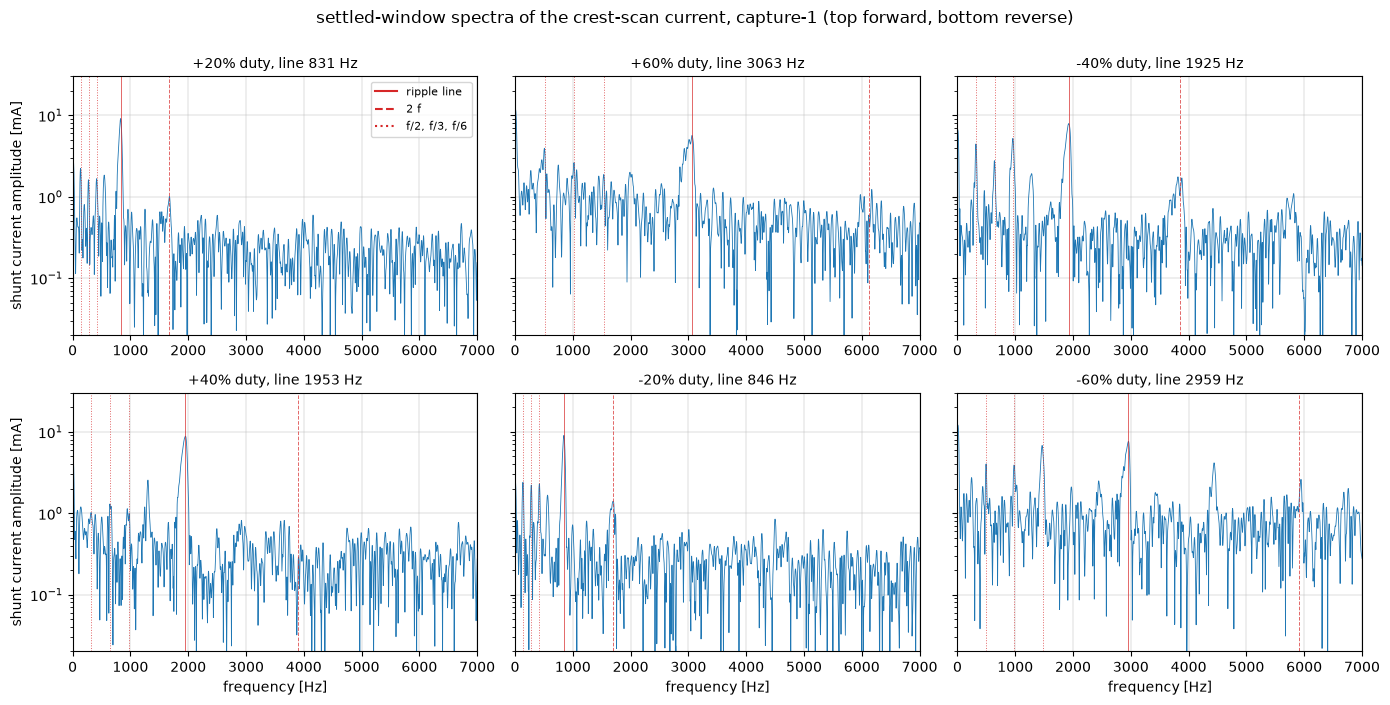

f_line_Hz                     width_Hz                   width_pct               amp_mA                line_over_floor                 mean_current_A               pot_speed_Vps  \
                       mean       min       max     mean      min      max      mean    min    max   mean    min     max            mean     min     max           mean    min    max          mean   
mag_pct direction                                                                                                                                                                                     
20      forward     833.615   827.909   842.884   49.653   46.875   53.819     5.957  5.613  6.477  9.714  9.082  10.092          40.539  37.011  43.494          0.069  0.068  0.070         3.042   
        reverse     833.527   822.464   845.777   47.569   45.139   50.347     5.708  5.361  6.080  8.491  8.067   9.023          30.751  26.900  35.017          0.062  0.061  0.063        -3.555   
40      forward    1931.112  1918.292  1952.934   98.264   86.806  105.903     5.088  4.503  5.521  8.966  8.627   9.531          28.423  26.518  30.337          0.102  0.101  0.103         7.419   
        reverse    1914.196  1897.153  1937.934   92.014   86.806   95.486     4.808  4.479  5.033  8.020  7.868   8.164          23.161  22.326  24.375          0.102  0.101  0.103        -7.468   
60      forward    3011.723  2988.278  3063.046  146.528  125.000  192.708     4.867  4.166  6.449  6.180  5.635   6.687          12.430   8.836  14.969          0.122  0.119  0.124        11.644   
        reverse    2949.485  2938.820  2958.755   77.431   62.500   92.014     2.625  2.113  3.124  7.413  6.823   7.627           9.202   8.238   9.991          0.115  0.114  0.117       -11.415   

                                  tone_width_Hz  
                      min     max         floor  
mag_pct direction                                
20      forward     2.973   3.152          24.3  
        reverse    -3.625  -3.492          24.3  
40      forward     7.381   7.504          24.3  
        reverse    -7.524  -7.412          24.3  
60      forward    11.568  11.723          24.3  
        reverse   -11.462 -11.364          24.3

In [4]:
F_LO, F_HI = 200.0, 6000.0
SETTLED = 0.6

def line_spectrum(x, nfft_mult=8):
    # Amplitude spectrum in the units of x, coherent gain of the Hann window removed.
    x = detrend(x)
    w = get_window("hann", len(x))
    nfft = nfft_mult * len(x)
    return np.fft.rfftfreq(nfft, DT), np.abs(np.fft.rfft(x * w, nfft)) * 2 / w.sum()

def interp_peak(f, X, lo, hi):
    m = (f >= lo) & (f <= hi)
    Xm, fm = X[m], f[m]
    i = int(np.argmax(Xm))
    d = 0.0
    if 0 < i < len(Xm) - 1:
        a, b, c = np.log(Xm[i - 1]), np.log(Xm[i]), np.log(Xm[i + 1])
        d = 0.5 * (a - c) / (a - 2 * b + c)
    return fm[i] + d * (f[1] - f[0]), Xm[i]

def half_width(f, X, f0):
    m = (f >= 0.7 * f0) & (f <= 1.3 * f0)
    fm, Xm = f[m], X[m]
    i = int(np.argmax(Xm))
    above = Xm >= Xm[i] / 2
    lo = i
    while lo > 0 and above[lo - 1]:
        lo -= 1
    hi = i
    while hi < len(Xm) - 1 and above[hi + 1]:
        hi += 1
    return fm[hi] - fm[lo]

def settled_line(f, X):
    # Largest peak in the band. Where a peak at six, three or two times that
    # frequency is at least half as tall, the lower peak is a sub-line of the
    # family in section 5.3 and the upper one is the ripple line.
    f0, a0 = interp_peak(f, X, F_LO, F_HI)
    for k in (6, 3, 2):
        if k * f0 * 1.05 <= F_HI:
            fk, ak = interp_peak(f, X, k * f0 * 0.95, k * f0 * 1.05)
            if ak >= 0.5 * a0:
                return fk, ak
    return f0, a0

def tone_width():
    # Width of a pure tone through the same window and search, the resolution floor.
    n = int(round(2400 * SETTLED))
    x = np.sin(2 * np.pi * 1000.0 * np.arange(n) * DT)
    f, X = line_spectrum(x)
    return half_width(f, X, 1000.0)

def settled(seg):
    n0 = int(len(seg) * (1 - SETTLED))
    return seg.iloc[n0:]

def pot_speed(seg):
    # Least-squares slope of the wiper over the window, in wiper V/s.
    p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
    return np.polyfit(np.arange(len(p)) * DT, p, 1)[0]

def step_line(seg):
    st = settled(seg)
    x = st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0]
    f, X = line_spectrum(x)
    fr, amp = settled_line(f, X)
    noise = np.median(X[(f >= F_LO) & (f <= F_HI)])
    ratios = {}
    for label, k in [("2f", 2.0), ("f/2", 0.5), ("f/3", 1 / 3), ("f/6", 1 / 6)]:
        _, a = interp_peak(f, X, k * fr * 0.95, k * fr * 1.05)
        ratios[label] = a / amp
    vt = DIV_RATIO * (st["vmotor_a"].to_numpy() - st["vmotor_b"].to_numpy()).astype(float)
    ft, Xt = line_spectrum(vt)
    _, amp_t = interp_peak(ft, Xt, fr * 0.97, fr * 1.03)
    xb = st["current_trough"].to_numpy().astype(float) - st["bias"].iloc[0]
    fb, Xb = line_spectrum(xb)
    _, amp_b = interp_peak(fb, Xb, fr * 0.97, fr * 1.03)
    return {
        "duty_pct": seg["duty_pct"].iloc[0],
        "mag_pct": int(seg["mag_pct"].iloc[0]),
        "f_line_Hz": fr,
        "amp_counts": amp,
        "amp_mA": amp * A_PER_COUNT * 1e3,
        "noise_floor_counts": noise,
        "width_Hz": half_width(f, X, fr),
        "width_pct": half_width(f, X, fr) / fr * 100,
        "line_over_floor": amp / noise,
        "mean_current_A": x.mean() * A_PER_COUNT,
        "pot_speed_Vps": pot_speed(st),
        "terminal_ripple_mV": amp_t * V_ADC_PER_COUNT * 1e3,
        "brake_window_ripple_counts": amp_b,
        **{f"ratio_{k}": v for k, v in ratios.items()},
    }

lines = []
for name, (df, meta) in ripple.items():
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        row = step_line(seg)
        row.update({"recording": name, "seg": seg_id})
        lines.append(row)
lines = pd.DataFrame(lines)
lines["direction"] = np.where(lines["duty_pct"] > 0, "forward", "reverse")
lines["cycles_per_V"] = lines["f_line_Hz"] / lines["pot_speed_Vps"].abs()

name, (df, meta) = next(iter(ripple.items()))
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, (seg_id, seg) in zip(axes.T.flatten(), df[df["seg"] > 0].groupby("seg")):
    st = settled(seg)
    x = st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0]
    f, X = line_spectrum(x)
    fr = lines[(lines["recording"] == name) & (lines["seg"] == seg_id)]["f_line_Hz"].iloc[0]
    ax.semilogy(f, X * A_PER_COUNT * 1e3, lw=0.6, color="tab:blue")
    for k, ls in [(1, "-"), (2, "--"), (0.5, ":"), (1 / 3, ":"), (1 / 6, ":")]:
        ax.axvline(k * fr, color="tab:red", lw=0.7, ls=ls, alpha=0.7)
    ax.set_xlim(0, 7000)
    ax.set_ylim(0.02, 30)
    ax.set_title(f"{seg['duty_pct'].iloc[0]:+.0f}% duty, line {fr:.0f} Hz", fontsize=10)
    ax.grid(True, lw=0.3)
for ax in axes[1]:
    ax.set_xlabel("frequency [Hz]")
for ax in axes[:, 0]:
    ax.set_ylabel("shunt current amplitude [mA]")
axes[0, 0].plot([], [], "-", color="tab:red", label="ripple line")
axes[0, 0].plot([], [], "--", color="tab:red", label="2 f")
axes[0, 0].plot([], [], ":", color="tab:red", label="f/2, f/3, f/6")
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle(f"settled-window spectra of the crest-scan current, {name} (top forward, bottom reverse)", y=1.0)
plt.tight_layout()
plt.show()

cols = ["f_line_Hz", "width_Hz", "width_pct", "amp_mA", "line_over_floor", "mean_current_A", "pot_speed_Vps"]
tab = lines.groupby(["mag_pct", "direction"])[cols].agg(["mean", "min", "max"]).round(3)
tab[("tone_width_Hz", "floor")] = round(tone_width(), 1)
tab


### 5.2 Ripple frequency against pot speed, and the coupling

**The tracker.** A steady step alone gives one frequency and one speed.
The time-resolved motor angle needs the ripple phase through the whole
step, including the acceleration, where the line sweeps upward from zero.
The tracker below works in two passes. The first pass is a ridge track. A
10 ms Hann window slides over the current in 1 ms hops, starting at the
settled end of the step and walking backward, and in every window the peak
is sought within 15% of the peak of the previous window, a band that
excludes the neighboring members of the sub-line family of section 5.3
(the nearest sits at five sixths of the line) while the line itself moves
by at most 6% per hop at the steepest acceleration seen. The settled-end
seed is the line within 30% of the frequency the pot speed predicts
through a first estimate of the coupling, which keeps the seed off the
sub-lines of section 5.3. The track is accepted from the last window in
which the peak fails to stand at least twice above the median spectrum or
falls below 250 Hz, and the first 5 ms of the accepted track are dropped.
The second pass is a demodulation. The current is mixed down with the
phase of the ridge, low-passed at a quarter of the lowest ridge frequency
(a zero-phase filter run over a 50 ms extension at both ends), and the
unwrapped residual phase is added back. The result is
the ripple phase in cycles at every sample, exact to a fraction of a cycle
wherever the line is present, with the ridge's interpolation error removed.

For every steady step the figure plots the settled line frequency against
the settled pot speed, and for every accepted grid step from 30% to 55%
the line frequency and pot speed over the accepted window. The coupling
$C$ of a step is the demodulated cycle count divided by the pot travel
over the accepted window, which averages the pot's periodic error over
the whole travel and is the estimate carried forward. The table gives it
by duty and direction with the spread across recordings.


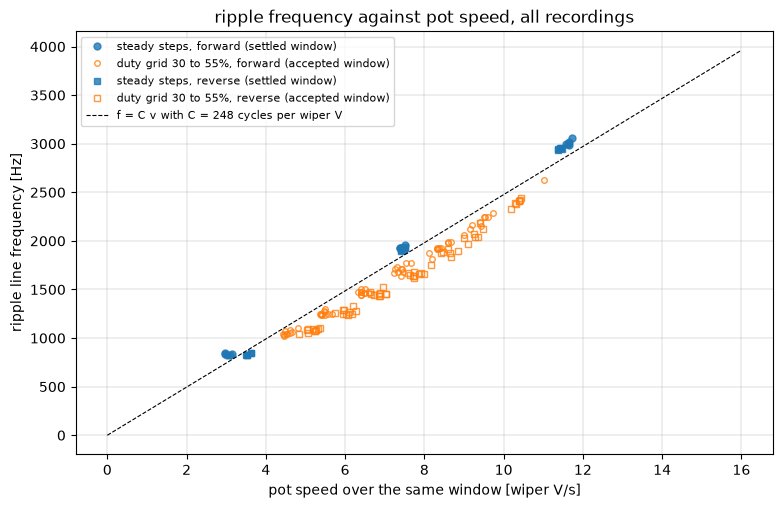

mean    std     min     max  count  travel_V
campaign     mag_pct direction                                                
duty grid    30      forward    258.96   4.90  249.08  268.64     10      0.30
                     reverse    230.57   5.64  224.98  243.01     10     -0.34
             35      forward    251.05   3.87  245.62  257.86     10      0.38
                     reverse    236.03   4.20  227.22  240.77     10     -0.39
             40      forward    252.30   5.36  243.26  260.17     10      0.44
                     reverse    236.73   4.02  232.21  244.94     10     -0.46
             45      forward    249.33   4.67  243.28  257.77     10      0.50
                     reverse    241.07   4.57  234.60  247.44     10     -0.52
             50      forward    250.89   2.25  248.01  255.87     10      0.56
                     reverse    243.23   3.90  237.56  250.39     10     -0.55
             55      forward    255.25   2.64  249.00  259.27     10      0.56
                     reverse    245.83   2.98  241.20  250.98     10     -0.56
steady steps 20      forward    254.85   6.31  248.87  265.04      5      0.30
                     reverse    239.08  10.96  227.44  252.98      5     -0.32
             40      forward    255.99   1.42  253.82  257.71      5      0.72
                     reverse    249.32   3.04  246.20  253.07      5     -0.73
             60      forward    256.14   2.15  252.87  257.94      5      0.99
                     reverse    250.04   2.08  248.46  253.03      4     -1.10

In [5]:
def ridge_track(x, seed, win=200, hop=20, tol=0.15, fmin=150.0, fmax=F_HI, nfft=8192):
    # Sliding-window peak track, walking backward from the end, seeded with the settled line.
    w = get_window("hann", win)
    f = np.fft.rfftfreq(nfft, DT)
    band = (f >= fmin) & (f <= fmax)
    out = []
    fprev = seed
    for c in np.arange(win // 2, len(x) - win // 2, hop)[::-1]:
        X = np.abs(np.fft.rfft(detrend(x[c - win // 2:c + win // 2]) * w, nfft)) * 2 / w.sum()
        fpk, amp = interp_peak(f, X, max(fmin, fprev * (1 - tol)), min(fmax, fprev * (1 + tol)))
        out.append((c, fpk, amp, np.median(X[band])))
        fprev = fpk
    return pd.DataFrame(out[::-1], columns=["n", "f", "amp", "noise"])

def demod_cycles(x, n_ref, f_ref, lp_frac=0.25):
    # Ripple phase in cycles at every sample: mix down with the ridge phase,
    # low-pass, unwrap the residual, add the ridge phase back.
    n = np.arange(len(x))
    fref = np.interp(n, n_ref, f_ref)
    phref = 2 * np.pi * np.cumsum(fref) * DT
    z = detrend(x) * np.exp(-1j * phref)
    sos = butter(3, max(30.0, lp_frac * fref.min()), "lowpass", fs=TICK_HZ, output="sos")
    zb = sosfiltfilt(sos, z, padlen=min(1000, len(z) - 1))
    return (phref + np.unwrap(np.angle(zb))) / (2 * np.pi)

def motor_angle(seg, c_prior, snr_min=2.0, f_floor=250.0, prior_tol=0.3):
    # Cycles at every sample of a drive step and the first accepted sample.
    x = seg["current_raw"].to_numpy().astype(float) - seg["bias"].iloc[0]
    st = settled(seg)
    v = abs(pot_speed(st))
    f, X = line_spectrum(x[len(seg) - len(st):])
    seed, _ = interp_peak(f, X, max(F_LO, c_prior * v * (1 - prior_tol)), min(F_HI, c_prior * v * (1 + prior_tol)))
    r = ridge_track(x, seed)
    ok = ((r["amp"] / r["noise"] >= snr_min) & (r["f"] >= f_floor)).to_numpy()
    bad = np.where(~ok)[0]
    r = r.iloc[bad.max() + 1:] if len(bad) else r
    cyc = demod_cycles(x, r["n"].to_numpy(), r["f"].to_numpy())
    return cyc, int(r["n"].iloc[0]) + 100, r

# First estimate of the coupling from the settled 20% and 40% lines, which
# are unambiguous (section 5.3), used only to seed the tracker.
C_PRIOR = lines[lines["mag_pct"] <= 40]["cycles_per_V"].median()
MIN_TRAVEL_V = 0.15

def track_step(seg, campaign, name):
    d = np.sign(seg["duty_pct"].iloc[0])
    cyc, n0, r = motor_angle(seg, C_PRIOR)
    if n0 >= len(seg) - 200:
        return None, None
    p = seg["pos"].to_numpy()[n0:] * V_ADC_PER_COUNT
    th = (cyc[n0:] - cyc[n0]) * d
    if p.max() - p.min() < MIN_TRAVEL_V:
        return None, None
    k = np.polyfit(th, p, 1)
    win = seg.iloc[n0:]
    row = {
        "campaign": campaign, "recording": name, "seg": int(seg["seg"].iloc[0]),
        "mag_pct": int(seg["mag_pct"].iloc[0]),
        "direction": "forward" if d > 0 else "reverse",
        "cycles": th[-1], "travel_V": p[-1] - p[0],
        "cycles_per_V": th[-1] / (p[-1] - p[0]),
        "mV_per_cycle_fit": k[0] * 1e3,
        "residual_rms_mV": (p - np.polyval(k, th)).std() * 1e3,
        "accepted_from_ms": n0 * DT * 1e3,
        "window_line_Hz": r["f"].mean(),
        "window_pot_speed_Vps": abs(pot_speed(win)),
        "p_lo_V": p.min(), "p_hi_V": p.max(),
    }
    trace = pd.DataFrame({"campaign": campaign, "recording": name, "seg": row["seg"],
                          "mag_pct": row["mag_pct"], "direction": row["direction"],
                          "p": p, "theta": th, "res": p - np.polyval(k, th)})
    return row, trace

steps, traces = [], []
for name, (df, meta) in ripple.items():
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        row, trace = track_step(seg, "steady steps", name)
        if row:
            steps.append(row)
            traces.append(trace)
for name, (df, meta) in grid.items():
    for seg_id, seg in df[(df["mag_pct"] >= 30) & (df["mag_pct"] <= 55)].groupby("seg"):
        row, trace = track_step(seg, "duty grid", name)
        if row:
            steps.append(row)
            traces.append(trace)
steps = pd.DataFrame(steps)
traces = pd.concat(traces, ignore_index=True)

C_MEAN = steps["cycles"].abs().sum() / steps["travel_V"].abs().sum()     # travel-weighted, both campaigns
fig, ax = plt.subplots(figsize=(9, 5.5))
for dname, mk in [("forward", "o"), ("reverse", "s")]:
    g = lines[lines["direction"] == dname]
    ax.plot(g["pot_speed_Vps"].abs(), g["f_line_Hz"], mk, ms=5, color="tab:blue", alpha=0.8,
            label=f"steady steps, {dname} (settled window)")
    g = steps[(steps["campaign"] == "duty grid") & (steps["direction"] == dname)]
    ax.plot(g["window_pot_speed_Vps"], g["window_line_Hz"], mk, ms=4, mfc="none", color="tab:orange",
            alpha=0.8, label=f"duty grid 30 to 55%, {dname} (accepted window)")
vv = np.linspace(0, 16, 50)
ax.plot(vv, C_MEAN * vv, "k--", lw=0.8, label=f"f = C v with C = {C_MEAN:.0f} cycles per wiper V")
ax.set_xlabel("pot speed over the same window [wiper V/s]")
ax.set_ylabel("ripple line frequency [Hz]")
ax.set_title("ripple frequency against pot speed, all recordings")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

coupling = (steps.groupby(["campaign", "mag_pct", "direction"])["cycles_per_V"]
            .agg(["mean", "std", "min", "max", "count"]))
coupling["travel_V"] = steps.groupby(["campaign", "mag_pct", "direction"])["travel_V"].mean()
coupling.round(2)


In [6]:
def pooled_row(label, g):
    r = g["cycles_per_V"].agg(["mean", "std", "min", "max", "count"])
    r["travel_weighted"] = g["cycles"].abs().sum() / g["travel_V"].abs().sum()
    return {"set": label, **r}

pooled = pd.DataFrame([
    pooled_row("steady steps, all", steps[steps["campaign"] == "steady steps"]),
    pooled_row("steady steps, 40% and 60% (travel 0.7 V and above)", steps[(steps["campaign"] == "steady steps") & (steps["mag_pct"] >= 40)]),
    pooled_row("duty grid 30 to 55%, all", steps[steps["campaign"] == "duty grid"]),
    pooled_row("both campaigns", steps),
    {"set": "settled-window ratio f / v, steady steps", **lines["cycles_per_V"].agg(["mean", "std", "min", "max", "count"]),
     "travel_weighted": np.nan},
]).set_index("set")
pooled["spread_pct"] = (pooled["max"] - pooled["min"]) / pooled["mean"] * 100
pooled["mV_per_cycle"] = 1e3 / pooled["mean"]
pooled["motor_rev_per_wiper_V (from the stated input)"] = pooled["mean"] / PULSES_PER_REV
pooled.round(2)


,mean,std,min,max,count,travel_weighted,spread_pct,mV_per_cycle,motor_rev_per_wiper_V (from the stated input)
set,,,,,,,,,
"steady steps, all",250.93,7.96,227.44,265.04,29.0,252.01,14.98,3.99,41.82
"steady steps, 40% and 60% (travel 0.7 V and above)",253.02,3.90,246.20,257.94,19.0,253.03,4.64,3.95,42.17
"duty grid 30 to 55%, all",245.94,9.17,224.98,268.64,120.0,246.07,17.75,4.07,40.99
both campaigns,246.91,9.14,224.98,268.64,149.0,247.62,17.68,4.05,41.15
"settled-window ratio f / v, steady steps",257.06,12.25,232.87,283.49,30.0,NaN,19.69,3.89,42.84


### 5.3 Amplitude, harmonics and the line family


In [7]:
cols = ["mean_current_A", "amp_mA", "ratio_2f", "ratio_f/2", "ratio_f/3", "ratio_f/6",
        "terminal_ripple_mV", "brake_window_ripple_counts"]
tab = lines.groupby("mag_pct")[cols].agg(["mean", "min", "max"]).round(3)
tab[("amp_over_mean_current_pct", "mean")] = (lines["amp_mA"] / (lines["mean_current_A"] * 1e3)).groupby(lines["mag_pct"]).mean().round(3) * 100
tab[("terminal_ripple_per_current_ohm", "mean")] = (lines["terminal_ripple_mV"] / lines["amp_mA"]).groupby(lines["mag_pct"]).mean().round(3)
tab


mean_current_A               amp_mA                ratio_2f               ratio_f/2               ratio_f/3               ratio_f/6               terminal_ripple_mV                \
                  mean    min    max   mean    min     max     mean    min    max      mean    min    max      mean    min    max      mean    min    max               mean    min    max   
mag_pct                                                                                                                                                                                      
20               0.066  0.061  0.070  9.103  8.067  10.092    0.135  0.094  0.176     0.271  0.097  0.493     0.214  0.090  0.397     0.253  0.066  0.527              8.032  7.360  8.665   
40               0.102  0.101  0.103  8.493  7.868   9.531    0.149  0.071  0.229     0.511  0.129  0.839     0.245  0.141  0.368     0.288  0.084  0.562              5.549  5.151  6.112   
60               0.119  0.114  0.124  6.797  5.635   7.627    0.240  0.089  0.360     0.640  0.287  0.970     0.474  0.292  0.862     0.597  0.299  1.018              3.875  2.486  4.626   

        brake_window_ripple_counts               amp_over_mean_current_pct terminal_ripple_per_current_ohm  
                              mean    min    max                      mean                            mean  
mag_pct                                                                                                     
20                           0.161  0.128  0.243                      13.9                           0.884  
40                           0.153  0.119  0.214                       8.3                           0.655  
60                           0.212  0.126  0.275                       5.8                           0.566

Findings for section 5:

- **The line.** Every settled step shows one dominant line, at 834 Hz for
  20% duty in both directions (822 to 846 Hz over ten steps), 1931 Hz
  forward and 1914 Hz reverse at 40%, and 3012 Hz forward and 2949 Hz
  reverse at 60%. It stands 23 to 40 times above the median spectrum at
  20% and 40% and 9 to 12 times at 60%, where the noise floor rises with
  the current. In one 60% step the sub-line at one sixth reaches 1.02
  times the line (table in section 5.3) and the family rule of section
  5.1 recovers the line.
- **Width.** The full width at half amplitude is 48 to 50 Hz at 20%
  (6% of the line), 92 to 98 Hz at 40% (5%), and 77 Hz reverse to 147 Hz
  forward at 60% (2.6% to 4.9%), against 24 Hz for a pure tone through
  the same window. *Hypothesis (not tested here): the excess width is the
  chirp of a speed still rising in the settled window, which starts 48 ms
  into the step, under three of the 17 to 21 ms mechanical time constants
  of notebook 04, so a speed rise of a few percent inside the window is
  expected and a few percent of the line is the order of the widths
  measured.*
- **Frequency against speed.** The line frequency is proportional to the
  pot speed with a slope of 257 cycles per wiper volt over the thirty
  settled windows (233 to 283, a 20% spread), where the spread is the
  pot's own periodic error over windows of 0.3 to 1 V (section 6). The
  duty-grid points fall on the same line, the reverse points a few percent
  below it, which section 6.2 traces to the position of those steps.
- **The coupling.** Counted as demodulated cycles per volt of travel, the
  40% and 60% steady steps give 253 cycles per wiper volt (246 to 258 over
  19 steps, a 4.6% spread), the 20% steps and the grid steps spread from
  225 to 269, and both campaigns together give 248 cycles per wiper volt
  travel-weighted, 4.04 mV of wiper per cycle. With the stated six pulses
  per revolution that is 41 motor revolutions per wiper volt. The spread
  between groups follows position. Forward steps, which run at 0.75 to
  1.9 V, give 249 to 259 on average, and reverse steps confined to the top
  of the range, 2.1 to 2.6 V, give 231 to 239, which is the subject of
  section 6.
- **Amplitude.** The line amplitude is 9.1 mA at 20% (8.1 to 10.1), 8.5 mA
  at 40% and 6.8 mA at 60%, which is 14%, 8% and 6% of the mean drive
  current. The same ripple appears on the terminal difference at 8.0, 5.5
  and 3.9 mV, which is 0.88 Ohm per ampere of ripple at 20% and 0.57 Ohm
  at 60%. *Hypothesis (not tested here): the terminal ripple is the current
  ripple across the on-resistance of the bridge and the shunt, 0.3 Ohm
  on the low side alone by notebook 01.* The brake-window shunt sample
  carries no line at all, 0.15 to 0.21 counts against a floor of the
  same size, so the ripple is a drive-window feature and the trough scan
  cannot serve as a tachometer.
- **Harmonics and sub-lines.** The second harmonic is 0.13 to 0.24 of the
  line. Below the line there is a family of sub-lines at one half, one
  third and one sixth of its frequency, all growing with duty, from 0.27,
  0.21 and 0.25 of the line at 20% to 0.64, 0.47 and 0.60 at 60%. With six
  pulses per revolution these are the first, second and third harmonics of
  a once-per-revolution modulation. *Hypothesis (not tested here): the
  modulation is a brush or commutator asymmetry that makes the six
  commutation steps of a revolution unequal, and it grows with current
  because the step size grows with current. The data cannot tell a
  single pulse per line cycle from a close pair, so the conversion to
  revolutions rests entirely on the stated input.*


## 6. Pot linearity

### 6.1 Motor-side angle against the pot inside a step

The demodulated ripple phase of section 5.2 is a motor-side angle in
cycles at every sample. Within one step the pot position is plotted
against it and a line is fitted. The residual of the pot from that line is
the pot's departure from proportionality to the motor angle, in wiper
volts, as a function of position. The left panel shows one 60% step, with
the motor angle and the pot against time. The right panel overlays the
residual of every accepted 40% step of the steady-step campaign against
absolute position, forward and reverse. Every trace has its own fitted
line, so the offsets between traces carry no information and the shapes
do.


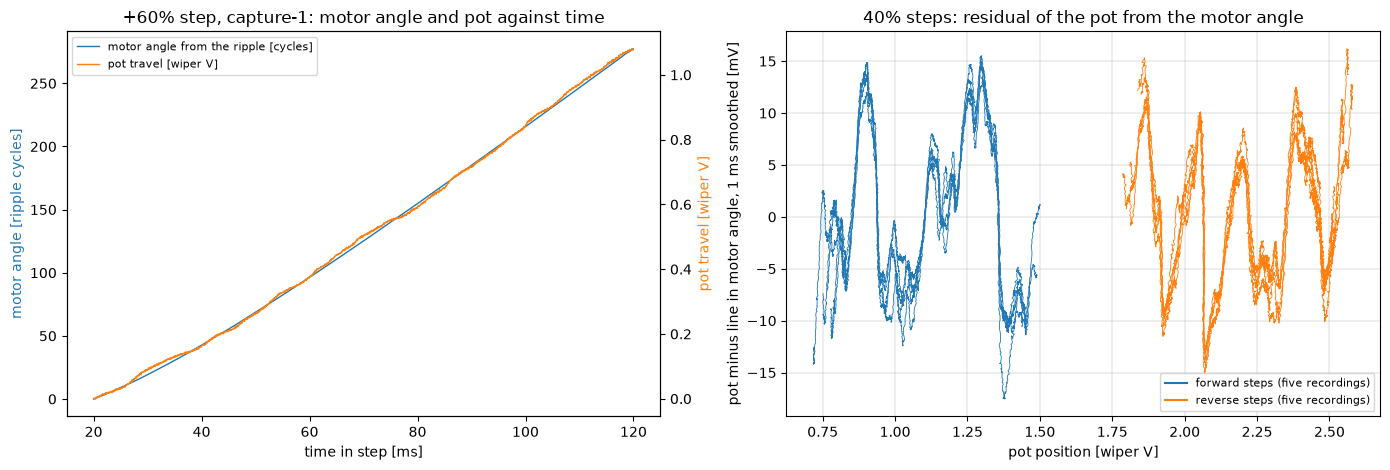

cycles_per_V                 residual_rms_mV             travel_V             accepted_from_ms            
                          mean     min     max            mean   min   max     mean   min   max             mean   min   max
mag_pct direction                                                                                                           
20      forward         254.85  248.87  265.04            7.25  6.84  7.86     0.30  0.28  0.30             20.8  20.0  22.0
        reverse         239.08  227.44  252.98            5.52  4.99  5.90    -0.32 -0.33 -0.29             20.2  14.0  22.0
40      forward         255.99  253.82  257.71            7.67  7.33  8.22     0.72  0.71  0.72             10.6  10.0  12.0
        reverse         249.32  246.20  253.07            6.62  6.27  7.37    -0.73 -0.74 -0.72             10.2  10.0  11.0
60      forward         256.14  252.87  257.94            7.41  6.73  8.57     0.99  0.84  1.09             30.0  17.0  47.0
        reverse         250.04  248.46  253.03            7.10  6.65  7.49    -1.10 -1.14 -1.03             16.5  10.0  25.0

In [8]:
name, (df, meta) = next(iter(ripple.items()))
seg = df[df["seg"] == 3]
cyc, n0, r = motor_angle(seg, C_PRIOR)
t = np.arange(len(seg)) * DT * 1e3
p = seg["pos"].to_numpy() * V_ADC_PER_COUNT

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
ax.plot(t[n0:], cyc[n0:] - cyc[n0], color="tab:blue", lw=1, label="motor angle from the ripple [cycles]")
ax.set_xlabel("time in step [ms]")
ax.set_ylabel("motor angle [ripple cycles]", color="tab:blue")
ax2 = ax.twinx()
ax2.plot(t[n0:], p[n0:] - p[n0], color="tab:orange", lw=1, label="pot travel [wiper V]")
ax2.set_ylabel("pot travel [wiper V]", color="tab:orange")
ax.set_title(f"+60% step, {name}: motor angle and pot against time")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
ax = axes[1]
for (rec, sid), g in traces[(traces["campaign"] == "steady steps") & (traces["mag_pct"] == 40)].groupby(["recording", "seg"]):
    rs = np.convolve(g["res"].to_numpy(), np.ones(20) / 20, mode="same")
    ax.plot(g["p"].to_numpy()[10:-10], rs[10:-10] * 1e3, lw=0.6,
            color="tab:blue" if g["direction"].iloc[0] == "forward" else "tab:orange")
ax.plot([], [], color="tab:blue", label="forward steps (five recordings)")
ax.plot([], [], color="tab:orange", label="reverse steps (five recordings)")
ax.set_xlabel("pot position [wiper V]")
ax.set_ylabel("pot minus line in motor angle, 1 ms smoothed [mV]")
ax.set_title("40% steps: residual of the pot from the motor angle")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

cols = ["cycles_per_V", "residual_rms_mV", "travel_V", "accepted_from_ms"]
steps[steps["campaign"] == "steady steps"].groupby(["mag_pct", "direction"])[cols].agg(["mean", "min", "max"]).round(2)


### 6.2 Wiper volts per ripple cycle against position

The local gain of the pot is the slope of position against motor angle
within a bin of position. It is fitted in consecutive windows of five
cycles (about 20 mV) on every accepted trace of both campaigns, each
window placed at its mean position, and pooled in 20 mV bins of position,
which needs no alignment between traces since a slope has no offset.
Windows are cut on the motor angle, the independent variable of the fit,
so the pooled slope is unbiased. The figure shows the pooled
local gain against position with the spread across traces, and the table
reduces it to 0.25 V bands. Two more figures of merit follow. The
reproducibility of the pattern is the rms difference between the residual
traces of different recordings at the same positions, taken within each
group of steps that covers the same range. The lower panel integrates the
pooled gain into the pot's departure from proportionality over the whole
covered range, one curve free of per-trace offsets, and the quasi-period
of the pattern is the spacing of its successive maxima. The last two rows
of the summary give the extreme local gains with their positions in the
min column.


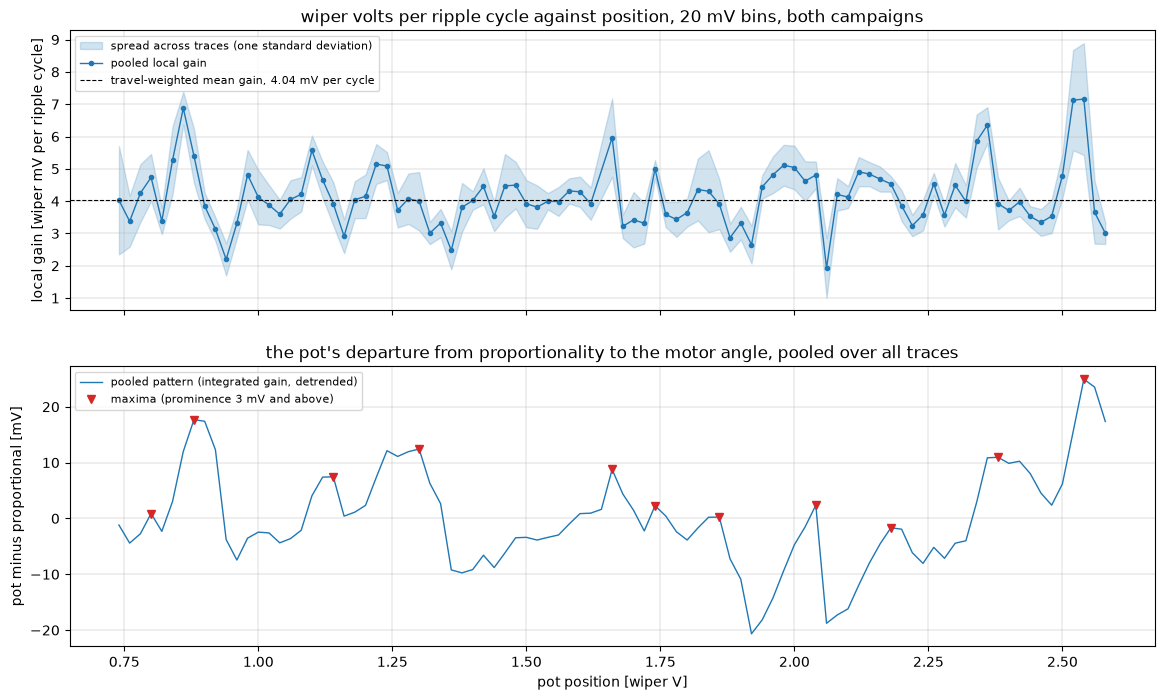

,mV_per_cycle,cycles_per_V,gain_min,gain_min_at_V,gain_max,gain_max_at_V,within_band_swing_pct,traces_per_bin
band_V,,,,,,,,
0.50,4.03,248.15,4.03,0.74,4.03,0.74,0.00,13.00
0.75,3.89,257.40,2.20,0.94,6.88,0.86,111.01,69.67
1.00,4.13,242.25,2.91,1.16,5.57,1.10,62.34,52.23
1.25,3.63,275.83,2.48,1.36,4.50,1.48,53.27,19.42
1.50,4.05,246.87,3.22,1.68,5.96,1.66,66.99,9.08
1.75,3.88,257.81,2.65,1.92,5.11,1.98,63.54,14.67
2.00,3.89,256.98,1.93,2.06,5.04,2.00,74.36,46.46
2.25,4.10,244.05,3.34,2.46,6.35,2.36,71.18,70.17
2.50,5.27,189.85,3.01,2.58,7.16,2.54,80.61,28.20


In [9]:
BIN_V = 0.02
WIN_CYCLES = 5

def local_gains(trace):
    # Slope of position against motor angle in consecutive windows of five
    # cycles (about 20 mV), each placed at its mean position. Windows are cut
    # on the motor angle, the independent variable, so the slope is unbiased.
    p, th = trace["p"].to_numpy(), trace["theta"].to_numpy()
    out = []
    for a in np.arange(th.min(), th.max() - WIN_CYCLES, WIN_CYCLES):
        m = (th >= a) & (th < a + WIN_CYCLES)
        if m.sum() >= 20:
            out.append({"bin_V": np.round(p[m].mean() / BIN_V) * BIN_V,
                        "mV_per_cycle": np.polyfit(th[m], p[m], 1)[0] * 1e3})
    return pd.DataFrame(out)

gains = []
for (camp, rec, sid), g in traces.groupby(["campaign", "recording", "seg"]):
    lg = local_gains(g)
    lg["campaign"], lg["recording"], lg["seg"], lg["direction"] = camp, rec, sid, g["direction"].iloc[0]
    gains.append(lg)
gains = pd.concat(gains, ignore_index=True)
gmap = gains.groupby("bin_V")["mV_per_cycle"].agg(["mean", "std", "count"]).reset_index()
gmap = gmap[gmap["count"] >= 8].sort_values("bin_V").reset_index(drop=True)
G_MEAN = 1e3 / C_MEAN

# Pooled pattern: the residual of the pot from proportionality, integrated
# from the pooled gain over a contiguous 20 mV grid (missing bins take the
# mean gain), then detrended.
gridp = np.arange(gmap["bin_V"].min(), gmap["bin_V"].max() + BIN_V / 2, BIN_V)
gain_on_grid = np.interp(gridp, gmap["bin_V"], gmap["mean"])
gain_on_grid[np.abs(gridp[:, None] - gmap["bin_V"].to_numpy()[None, :]).min(axis=1) > BIN_V / 2] = G_MEAN
pattern = np.cumsum((1 - G_MEAN / gain_on_grid) * BIN_V)
pattern -= np.polyval(np.polyfit(gridp, pattern, 1), gridp)
pk_idx, _ = find_peaks(pattern, prominence=0.003)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax = axes[0]
ax.fill_between(gmap["bin_V"], gmap["mean"] - gmap["std"], gmap["mean"] + gmap["std"], color="tab:blue", alpha=0.2,
                label="spread across traces (one standard deviation)")
ax.plot(gmap["bin_V"], gmap["mean"], "-o", ms=3, lw=1, color="tab:blue", label="pooled local gain")
ax.axhline(G_MEAN, color="k", lw=0.8, ls="--", label=f"travel-weighted mean gain, {G_MEAN:.2f} mV per cycle")
ax.set_ylabel("local gain [wiper mV per ripple cycle]")
ax.set_title("wiper volts per ripple cycle against position, 20 mV bins, both campaigns")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
ax.plot(gridp, pattern * 1e3, "-", lw=1, color="tab:blue", label="pooled pattern (integrated gain, detrended)")
ax.plot(gridp[pk_idx], pattern[pk_idx] * 1e3, "v", color="tab:red", ms=6, label="maxima (prominence 3 mV and above)")
ax.set_xlabel("pot position [wiper V]")
ax.set_ylabel("pot minus proportional [mV]")
ax.set_title("the pot's departure from proportionality to the motor angle, pooled over all traces")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

gmap["band_V"] = (gmap["bin_V"] // 0.25) * 0.25
bands = gmap.groupby("band_V").apply(lambda g: pd.Series({
    "mV_per_cycle": np.average(g["mean"], weights=g["count"]),
    "cycles_per_V": 1e3 / np.average(g["mean"], weights=g["count"]),
    "gain_min": g["mean"].min(), "gain_min_at_V": g.loc[g["mean"].idxmin(), "bin_V"],
    "gain_max": g["mean"].max(), "gain_max_at_V": g.loc[g["mean"].idxmax(), "bin_V"],
    "within_band_swing_pct": (g["mean"].max() - g["mean"].min()) / g["mean"].mean() * 100,
    "traces_per_bin": g["count"].mean(),
}), include_groups=False)
bands.round(2)


In [10]:
# Reproducibility: rms difference between residual traces of different
# recordings within a group that covers the same range, on a 2 mV grid.
def group_repro(g):
    lo = g.groupby(["recording", "seg"])["p"].min().max() + 0.01
    hi = g.groupby(["recording", "seg"])["p"].max().min() - 0.01
    if hi - lo < 0.1:
        return None
    gridp = np.arange(lo, hi, 0.002)
    curves = []
    for (rec, sid), t in g.groupby(["recording", "seg"]):
        order = np.argsort(t["p"].to_numpy())
        c = np.interp(gridp, t["p"].to_numpy()[order], t["res"].to_numpy()[order])
        curves.append(c - np.polyval(np.polyfit(gridp, c, 1), gridp))
    curves = np.array(curves)
    mean = curves.mean(axis=0)
    return {"traces": len(curves), "range_V": hi - lo,
            "pattern_rms_mV": mean.std() * 1e3,
            "pattern_pk_pk_mV": (mean.max() - mean.min()) * 1e3,
            "between_trace_rms_mV": (curves - mean).std() * 1e3}

rows = []
for (camp, mag, dname), g in traces.groupby(["campaign", "mag_pct", "direction"]):
    r = group_repro(g)
    if r:
        rows.append({"campaign": camp, "mag_pct": mag, "direction": dname, **r})
repro = pd.DataFrame(rows).set_index(["campaign", "mag_pct", "direction"])

# Quasi-period of the pooled pattern: spacing of its successive maxima.
spacing = np.diff(gridp[pk_idx])
summary = repro.agg(["mean", "min", "max"]).T
summary.loc["pooled_pattern_maxima_spacing_V"] = [spacing.mean(), spacing.min(), spacing.max()]
summary.loc["pooled_pattern_maxima_count"] = [len(pk_idx), np.nan, np.nan]
summary.loc["pooled_pattern_rms_mV"] = [pattern.std() * 1e3, np.nan, np.nan]
summary.loc["pooled_pattern_pk_pk_mV"] = [(pattern.max() - pattern.min()) * 1e3, np.nan, np.nan]
summary.loc["pooled_gain_min_mV_per_cycle"] = [gmap["mean"].min(), gmap.loc[gmap["mean"].idxmin(), "bin_V"], np.nan]
summary.loc["pooled_gain_max_mV_per_cycle"] = [gmap["mean"].max(), gmap.loc[gmap["mean"].idxmax(), "bin_V"], np.nan]
summary.round(3)


,mean,min,max
traces,8.278,4.000,10.000
range_V,0.433,0.222,0.991
pattern_rms_mV,6.151,3.373,8.439
pattern_pk_pk_mV,23.192,12.366,32.267
between_trace_rms_mV,1.748,1.293,1.933
pooled_pattern_maxima_spacing_V,0.174,0.080,0.360
pooled_pattern_maxima_count,11.000,NaN,NaN
pooled_pattern_rms_mV,8.929,NaN,NaN
pooled_pattern_pk_pk_mV,45.588,NaN,NaN
pooled_gain_min_mV_per_cycle,1.931,2.060,NaN


Findings for section 6:

- **The pot departs from proportionality to the motor angle within a step.** The
  residual of the pot from the fitted line has an rms of 5.0 to 8.6 mV in
  the steady steps (5.5 to 7.7 mV on average by group), against a position
  noise of 1.4 to 1.6 mV rms, and it is a pattern in position. The traces
  of a group overlay each other to 1.3 to 1.9 mV rms at the same positions
  (1.7 mV on average over all groups), which is the pot's own noise level,
  while the pattern itself
  has 12 to 32 mV peak to peak within a group and 46 mV peak to peak
  pooled over the whole covered range of 0.74 to 2.58 V. The pattern is
  therefore a fixed function of position on the output side of the gear
  train.
- **The local gain swings by a factor of three.** The wiper volts per
  ripple cycle in 20 mV bins run from 1.9 mV per cycle at 2.06 V to
  7.2 mV per cycle at 2.54 V around a travel-weighted mean of 4.04, with
  swings of 53% to 111% within every 0.25 V band from 0.75 V up. Averaged
  over 0.25 V bands the gain stays within 3.6 to 4.1 mV per cycle from
  0.75 to 2.5 V (242 to 276 cycles per wiper volt), and the stub above
  2.5 V reads 5.3. The coupling therefore depends on position by 13%
  between 0.25 V bands and by a factor of 3.7 between 20 mV bins.
- **This is the speed ripple of notebook 01.** The pot-derived speed is
  the motor speed times the local gain, so a gain that swings by half
  within 0.2 V produces a speed ripple of the same relative size at the
  same spatial period. The pooled pattern has eleven maxima over 1.84 V,
  0.17 V apart on average (0.08 to 0.36), matching the 0.1 to 0.2 V
  period notebook 01 read from the speed. The motor-side angle carries
  none of it, since the ripple line is 3% to 6% wide (section 5.1).
  *Hypothesis (not tested here): the pattern is the tooth-to-tooth
  transmission error of the last gear stage, whose tooth pitch in wiper
  volts would be the 0.17 V quasi-period, superposed on a slower
  nonlinearity of the pot track. A pot track error alone would have no
  reason to repeat at a fixed pitch. Since every gear angle is a fixed
  function of output angle in a train without slip, either source repeats
  from recording to recording, and the two are separated only by
  replacing the pot or the gear.*
- **Sharp features.** The pattern is far from a sinusoid. At 2.06 V the
  pot advances at half the mean rate over one 20 mV bin, and at 0.86,
  2.36 and 2.54 V at 1.6 to 1.8 times the mean rate (the band extremes of
  the table), in every recording and both directions. These are the steepest parts of the pattern and
  the places where a pot-based speed estimate is furthest off.


## 7. Gear play

### 7.1 One reversal

At a flip the drive current jumps to several times its steady value and
then decays as the motor decelerates, reverses and speeds up in the new
direction, and the commutation steps ride on it. Near zero speed the steps
are milliseconds apart and each is a one-sample jump of tens of counts, so
the spectral tracker of section 5.2 gives way to a step detector. A
commutation step is a one-sample change of the current that exceeds 10% of
the local current (21-sample median) and at least 10 counts, with jumps
within four samples of each other merged into one. The sensitivity of every
count to that threshold is reported alongside it, at 8% and 12%.

Three instants are read from each flip. The pot's stop $t_{stop}$ and
resumption $t_{res}$ bound the plateau of the position, smoothed over
1 ms, within two counts (1.6 mV) of its extreme value. The motor's zero
crossing $t_m$ is the midpoint of the widest interval between consecutive
commutation steps within 3 to 30 ms after the flip, where the step rate
passes through zero. The dwell is $t_{res} - t_{stop}$. The dwell travel
is the number of commutation steps within the dwell divided by the coupling
$C$ of section 5.2, the wiper-equivalent travel of the motor while the pot
stands still, and is this notebook's measure of the gear play. The
overshoot is the pot's travel in the old direction after the flip, the
braking distance. The figure follows one 40% flip.


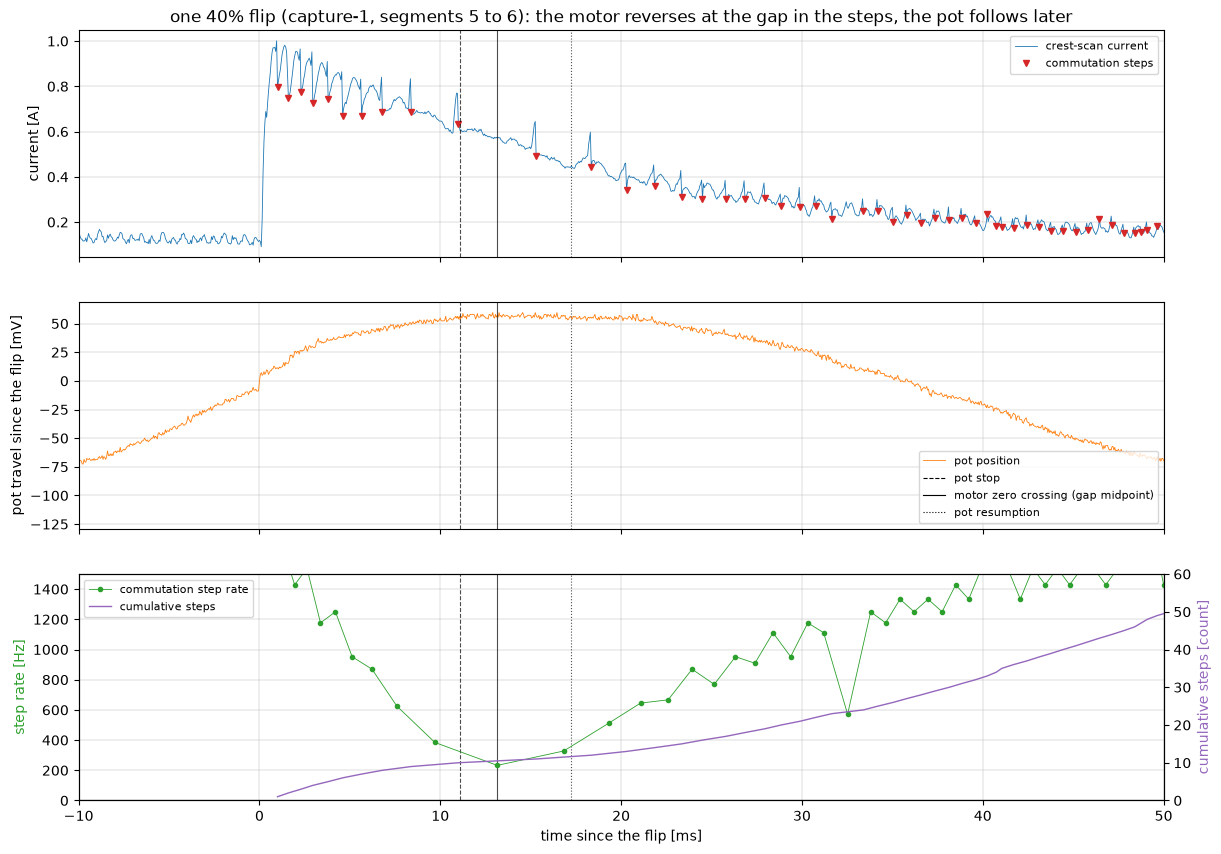

,value
mag_pct,40
old_direction,forward
f_pre_Hz,1689.722997
v_pre_Vps,5.305984
peak_current_A,0.911645
overshoot_mV,65.460205
t_stop_ms,11.1
t_res_ms,17.25
steps_in_dwell_8pct,1
steps_in_dwell,1


In [11]:
def step_events(x, frac=0.10, floor=10, dist=4):
    # Commutation steps: one-sample jumps above a threshold scaled to the local current.
    d1 = np.zeros_like(x)
    d1[1:] = np.diff(x)
    thr = np.maximum(floor, frac * np.abs(medfilt(x, 21)))
    ev = []
    for k in np.where(np.abs(d1) >= thr)[0]:
        if ev and k - ev[-1][0] <= dist:
            if abs(d1[k]) > abs(ev[-1][1]):
                ev[-1] = (k, d1[k])
        else:
            ev.append((k, d1[k]))
    return np.array([e[0] for e in ev], dtype=int)

PLATEAU_COUNTS = 2
EDGE = 10          # samples excluded at both ends of the post-flip segment (inductive rise, segment end)

def analyze_flip(pre, post, C):
    old = np.sign(pre["duty_pct"].iloc[0])
    x = post["current_raw"].to_numpy().astype(float) - post["bias"].iloc[0]
    p = post["pos"].to_numpy().astype(float) * old              # old direction positive
    p0 = np.median(pre["pos"].to_numpy()[-10:]) * old
    ps = np.convolve(p, np.ones(20) / 20, mode="same")
    top = ps[EDGE:-EDGE].max()
    within = np.where(np.abs(ps - top) <= PLATEAU_COUNTS)[0]
    within = within[(within >= EDGE) & (within < len(p) - EDGE)]
    k_stop, k_res = within.min(), within.max()
    f, X = line_spectrum(pre["current_raw"].to_numpy()[-400:].astype(float))
    f_pre, _ = settled_line(f, X)
    out = {
        "mag_pct": int(post["mag_pct"].iloc[0]),
        "old_direction": "forward" if old > 0 else "reverse",
        "f_pre_Hz": f_pre,
        "v_pre_Vps": pot_speed(pre.iloc[-400:]) * old,
        "peak_current_A": np.median(x[EDGE:60]) * A_PER_COUNT,
        "overshoot_mV": (top - p0) * V_ADC_PER_COUNT * 1e3,
        "t_stop_ms": k_stop * DT * 1e3,
        "t_res_ms": k_res * DT * 1e3,
    }
    for frac, tag in [(0.08, "steps_in_dwell_8pct"), (0.10, "steps_in_dwell"), (0.12, "steps_in_dwell_12pct")]:
        ev = step_events(x, frac=frac)
        ev = ev[(ev >= EDGE) & (ev < len(x) - EDGE)]
        out[tag] = int(np.sum((ev > k_stop) & (ev < k_res)))
        if frac == 0.10:
            te = ev * DT * 1e3
            mid, gap = (te[1:] + te[:-1]) / 2, np.diff(te)
            m = (mid > 3) & (mid < 30)
            g = np.argmax(gap[m])
            out["t_m_ms"] = mid[m][g]
            out["gap_ms"] = gap[m][g]
            near = (te > out["t_res_ms"] - 3) & (te < out["t_res_ms"] + 3)
            out["motor_rate_at_res_Hz"] = near.sum() / 6e-3
            events = ev
    out["dwell_ms"] = out["t_res_ms"] - out["t_stop_ms"]
    out["dwell_travel_mV"] = out["steps_in_dwell"] / C * 1e3
    out["t_stop_minus_t_m_ms"] = out["t_stop_ms"] - out["t_m_ms"]
    return out, events

C_STEADY = C_MEAN
flips = []
for name, (df, meta) in reversal.items():
    for a, b in flip_pairs(meta):
        row, _ = analyze_flip(df[df["seg"] == a], df[df["seg"] == b], C_STEADY)
        row.update({"recording": name, "flip": f"{a}->{b}"})
        flips.append(row)
flips = pd.DataFrame(flips)

name, (df, meta) = next(iter(reversal.items()))
a, b = flip_pairs(meta)[2]
pre, post = df[df["seg"] == a], df[df["seg"] == b]
row, events = analyze_flip(pre, post, C_STEADY)
both = pd.concat([pre.iloc[-400:], post])
n_pre = 400
x = both["current_raw"].to_numpy().astype(float) - both["bias"].iloc[0]
p = both["pos"].to_numpy() * V_ADC_PER_COUNT * 1e3
t = (np.arange(len(both)) - n_pre) * DT * 1e3
te = events * DT * 1e3
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(t, x * A_PER_COUNT, lw=0.6, color="tab:blue", label="crest-scan current")
axes[0].plot(te, x[events + n_pre] * A_PER_COUNT, "v", ms=4, color="tab:red", label="commutation steps")
axes[0].set_ylabel("current [A]")
axes[0].legend(fontsize=8, loc="upper right")
axes[1].plot(t, p - p[n_pre], lw=0.6, color="tab:orange", label="pot position")
for key, ls, lab in [("t_stop_ms", "--", "pot stop"), ("t_m_ms", "-", "motor zero crossing (gap midpoint)"), ("t_res_ms", ":", "pot resumption")]:
    for ax in axes:
        ax.axvline(row[key], color="k", lw=0.8, ls=ls, alpha=0.7)
    axes[1].plot([], [], "k", ls=ls, lw=0.8, label=lab)
axes[1].set_ylabel("pot travel since the flip [mV]")
axes[1].legend(fontsize=8, loc="lower right")
mid = (te[1:] + te[:-1]) / 2
axes[2].plot(mid, 1e3 / np.diff(te), "o-", ms=3, lw=0.6, color="tab:green", label="commutation step rate")
axes[2].set_ylabel("step rate [Hz]", color="tab:green")
axes[2].set_xlabel("time since the flip [ms]")
axes[2].set_ylim(0, 1500)
ax2 = axes[2].twinx()
ax2.plot(te, np.arange(1, len(te) + 1), "-", lw=1, color="tab:purple", label="cumulative steps")
ax2.set_ylabel("cumulative steps [count]", color="tab:purple")
ax2.set_ylim(0, 60)
h1, l1 = axes[2].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[2].legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
axes[2].set_xlim(-10, 50)
for ax in axes:
    ax.grid(True, lw=0.3)
axes[0].set_title(f"one 40% flip ({name}, segments {a} to {b}): the motor reverses at the gap in the steps, the pot follows later")
plt.show()

pd.DataFrame([row]).T.rename(columns={0: "value"}).round(2)


### 7.2 Play per direction and amplitude

The table pools the ten flips of each direction and amplitude over the five
recordings. Direction is the direction of the drive before the flip.


In [12]:
cols = ["f_pre_Hz", "v_pre_Vps", "peak_current_A", "overshoot_mV", "t_stop_ms", "t_m_ms", "gap_ms",
        "t_stop_minus_t_m_ms", "t_res_ms", "dwell_ms", "steps_in_dwell", "dwell_travel_mV",
        "motor_rate_at_res_Hz"]
play = flips.groupby(["mag_pct", "old_direction"])[cols].agg(["mean", "std", "min", "max"]).round(2)
play.T


mag_pct                        20               40         
old_direction             forward reverse  forward  reverse
f_pre_Hz             mean  709.60  694.52  1656.79  1629.19
                     std     9.00   14.70    41.78    47.24
                     min   700.50  674.84  1615.09  1579.80
                     max   725.30  723.53  1712.01  1685.51
v_pre_Vps            mean    3.52    3.40     6.39     6.28
                     std     0.61    0.71     0.78     1.46
                     min     2.63    2.47     5.31     4.55
                     max     4.24    4.61     7.33     7.80
peak_current_A       mean    0.36    0.37     0.89     0.89
                     std     0.01    0.01     0.01     0.01
                     min     0.35    0.36     0.88     0.89
                     max     0.38    0.38     0.91     0.90
overshoot_mV         mean   35.85   28.40    70.95    73.65
                     std     7.31    4.43     6.09     8.02
                     min    24.65   21.95    62.28    59.86
                     max    45.04   37.87    81.49    81.53
t_stop_ms            mean    9.05    8.39    11.34    11.49
                     std     1.05    1.15     0.81     0.55
                     min     7.40    6.95    10.05    10.70
                     max    10.50   11.00    12.25    12.25
t_m_ms               mean   12.91   12.16    12.50    12.56
                     std     2.17    1.94     0.94     0.19
                     min    11.25   11.02    10.30    12.25
                     max    16.23   16.20    13.15    12.80
gap_ms               mean    9.00    7.80     5.41     6.05
                     std     2.69    2.89     1.27     2.22
                     min     5.25    4.30     3.90     3.40
                     max    12.55   11.60     7.80    10.35
t_stop_minus_t_m_ms  mean   -3.86   -3.78    -1.15    -1.07
                     std     2.86    2.54     0.92     0.47
                     min    -8.83   -8.60    -2.75    -1.92
                     max    -1.15   -0.02     0.32    -0.52
t_res_ms             mean   17.79   19.71    16.50    17.68
                     std     2.93    3.13     1.31     1.34
                     min    14.15   14.65    14.75    15.20
                     max    23.70   24.40    18.70    19.15
dwell_ms             mean    8.74   11.32     5.16     6.19
                     std     3.00    3.32     1.30     1.36
                     min     4.15    5.95     2.50     3.80
                     max    13.20   16.55     6.65     7.85
steps_in_dwell       mean    1.40    2.40     1.00     1.30
                     std     1.26    2.17     0.82     0.82
                     min     0.00    0.00     0.00     0.00
                     max     3.00    7.00     2.00     2.00
dwell_travel_mV      mean    5.65    9.69     4.04     5.25
                     std     5.11    8.77     3.30     3.32
                     min     0.00    0.00     0.00     0.00
                     max    12.12   28.27     8.08     8.08
motor_rate_at_res_Hz mean  300.00  400.00   333.33   433.33
                     std   189.22   86.07   111.11   116.53
                     min     0.00  333.33   166.67   166.67
                     max   666.67  500.00   500.00   500.00

In [13]:
sens = flips.groupby(["mag_pct", "old_direction"])[["steps_in_dwell_8pct", "steps_in_dwell", "steps_in_dwell_12pct"]].mean()
sens["dwell_travel_mV_8pct"] = sens["steps_in_dwell_8pct"] / C_STEADY * 1e3
sens["dwell_travel_mV_12pct"] = sens["steps_in_dwell_12pct"] / C_STEADY * 1e3
sens["median_steps"] = flips.groupby(["mag_pct", "old_direction"])["steps_in_dwell"].median()
sens["flips"] = flips.groupby(["mag_pct", "old_direction"]).size()
allrow = pd.Series({
    "steps_in_dwell_8pct": flips["steps_in_dwell_8pct"].mean(), "steps_in_dwell": flips["steps_in_dwell"].mean(),
    "steps_in_dwell_12pct": flips["steps_in_dwell_12pct"].mean(),
    "dwell_travel_mV_8pct": flips["steps_in_dwell_8pct"].mean() / C_STEADY * 1e3,
    "dwell_travel_mV_12pct": flips["steps_in_dwell_12pct"].mean() / C_STEADY * 1e3,
    "median_steps": flips["steps_in_dwell"].median(), "flips": len(flips)}, name=("all", "all"))
sens = pd.concat([sens, allrow.to_frame().T])
sens["dwell_travel_mV"] = sens["steps_in_dwell"] / C_STEADY * 1e3
sens.round(2)


steps_in_dwell_8pct  steps_in_dwell  steps_in_dwell_12pct  dwell_travel_mV_8pct  dwell_travel_mV_12pct  median_steps  flips  dwell_travel_mV
20  forward                 2.00            1.40                   1.3                  8.08                   5.25           1.0   10.0             5.65
    reverse                 3.00            2.40                   2.0                 12.12                   8.08           2.0   10.0             9.69
40  forward                 1.10            1.00                   1.0                  4.44                   4.04           1.0   10.0             4.04
    reverse                 1.30            1.30                   1.3                  5.25                   5.25           1.5   10.0             5.25
all all                     1.85            1.52                   1.4                  7.47                   5.65           1.0   40.0             6.16

### 7.3 Slip signatures

Slip would show as motor cycles that the pot never sees outside a
reversal. Two tests cover it. Inside the steady steps, a slipped tooth
would shift the residual of section 6.1 by one cycle's worth of wiper
travel, 4 mV, at a position that differs from recording to recording.
The between-trace rms of section 6.2 already bounds that. The table
below adds, per group, the largest deviation of any single trace from the
group's mean pattern, in cycles. The second test looks for the pot
standing still while the motor turns, outside the reversal dwell. Within
every accepted trace, every run of at least 2 ms in which the 1 ms
smoothed pot stays within two counts is listed with the motor cycles it
contains, and the minimum local gain of section 6.2 gives the same test
in position bins.


In [14]:
def group_max_dev(g):
    lo = g.groupby(["recording", "seg"])["p"].min().max() + 0.01
    hi = g.groupby(["recording", "seg"])["p"].max().min() - 0.01
    if hi - lo < 0.1:
        return None
    gridp = np.arange(lo, hi, 0.002)
    curves = []
    for (rec, sid), t in g.groupby(["recording", "seg"]):
        order = np.argsort(t["p"].to_numpy())
        c = np.interp(gridp, t["p"].to_numpy()[order], t["res"].to_numpy()[order])
        curves.append(c - np.polyval(np.polyfit(gridp, c, 1), gridp))
    curves = np.array(curves)
    dev = np.abs(curves - curves.mean(axis=0)).max()
    return {"traces": len(curves), "max_single_trace_deviation_mV": dev * 1e3,
            "in_cycles": dev * C_MEAN}

rows = []
for (camp, mag, dname), g in traces.groupby(["campaign", "mag_pct", "direction"]):
    r = group_max_dev(g)
    if r:
        rows.append({"campaign": camp, "mag_pct": mag, "direction": dname, **r})
slip_a = pd.DataFrame(rows).set_index(["campaign", "mag_pct", "direction"])

# Pot standstills inside accepted traces.
stalls = []
for (camp, rec, sid), g in traces.groupby(["campaign", "recording", "seg"]):
    p = g["p"].to_numpy() / V_ADC_PER_COUNT
    th = g["theta"].to_numpy()
    ps = np.convolve(p, np.ones(20) / 20, mode="same")
    moving = np.abs(np.gradient(ps)) * 40 > PLATEAU_COUNTS     # more than 2 counts per 2 ms
    still = ~moving
    still[:10] = still[-10:] = False
    edges = np.diff(still.astype(int))
    starts, ends = np.where(edges == 1)[0] + 1, np.where(edges == -1)[0] + 1
    for s, e in zip(starts, ends):
        if e - s >= 40:
            stalls.append({"campaign": camp, "recording": rec, "seg": sid, "mag_pct": g["mag_pct"].iloc[0],
                           "position_V": g["p"].iloc[s], "duration_ms": (e - s) * DT * 1e3,
                           "motor_cycles": th[e] - th[s]})
stalls = pd.DataFrame(stalls)
slip_b = pd.DataFrame([{
    "accepted traces": traces.groupby(["campaign", "recording", "seg"]).ngroups,
    "standstills of 2 ms or more": len(stalls),
    "longest standstill [ms]": stalls["duration_ms"].max() if len(stalls) else 0.0,
    "most motor cycles in a standstill": stalls["motor_cycles"].abs().max() if len(stalls) else 0.0,
    "minimum local gain [mV per cycle]": gmap["mean"].min(),
    "maximum local gain [mV per cycle]": gmap["mean"].max(),
    "largest single-trace deviation [cycles]": slip_a["in_cycles"].max(),
}]).T.rename(columns={0: "value"})
slip_b.round(3)


,value
accepted traces,149.000
standstills of 2 ms or more,0.000
longest standstill [ms],0.000
most motor cycles in a standstill,0.000
minimum local gain [mV per cycle],1.931
maximum local gain [mV per cycle],7.159
largest single-trace deviation [cycles],2.575


Findings for section 7:

- **Braking.** After a flip the drive current jumps to 0.35 to 0.38 A at
  20% and 0.88 to 0.91 A at 40% and the output keeps moving in the old
  direction for 8.4 to 9.1 ms at 20% and 11.3 to 11.5 ms at 40% (pot
  stop, two-count threshold), covering 28 to 36 mV at 20% and 71 to 74 mV
  at 40% before it stops. That overshoot is the braking distance, about
  90 counts of the pot at 40%.
- **The motor reverses at 12 to 13 ms whatever the amplitude.** The gap
  in the commutation steps is centered at 12.2 to 12.9 ms after the flip
  at 20% and 12.5 to 12.6 ms at 40%, with gap widths of 8 to 9 ms and 5
  to 6 ms. The pot's stop precedes the gap center by 3.8 ms at 20% and
  1.1 ms at 40%, within the half-width of the gap, and the two-count
  threshold reads the stop early by the time the pot takes to cover its
  last 1.6 mV. The output therefore stops when the motor stops, which
  says the output is held against the motor's flank through the braking
  phase. *Hypothesis (not tested here): the braking time is independent of
  amplitude because both the speed to be cancelled and the braking current
  scale with duty, 3.4 to 3.5 wiper V/s against 0.37 A at 20% and 6.3 to
  6.4 wiper V/s against 0.89 A at 40%.*
- **The play.** Between the pot's stop and its resumption the motor makes
  1.0 to 1.3 commutation steps on average at 40% (0 to 2 in every flip)
  and 1.4 forward and 2.4 reverse at 20% (0 to 3 and 0 to 7), a median of
  1 to 2 steps over the forty flips. At 4.04 mV of wiper per cycle that
  is a dwell travel of 4.0 mV forward and 5.3 mV reverse at 40% and 5.7
  and 9.7 mV at 20%, with standard deviations of 3 to 9 mV, and 6.2 mV
  over all forty flips (median 4.0 mV). The count moves from 1.9 to 1.4
  steps per flip when the detector threshold goes from 8% to 12% of the
  current, so the threshold uncertainty is about half a step. The gear
  play seen by the pot is therefore one to two ripple cycles, 4 to 10 mV
  of wiper, 5 to 12 pot counts, and with the stated six pulses per
  revolution one sixth to one third of a motor revolution. The 20%
  reverse-pass flips carry the widest spread, with one flip of 7 steps
  (28 mV) and a dwell of 16.5 ms.
- **Resumption.** The pot resumes 5 to 6 ms after its stop at 40% and 9 to
  11 ms at 20%, when the motor's step rate has reached 300 to 430 Hz, 1.2
  to 1.7 wiper V/s equivalent. The dwell is longer at 20% because the
  motor accelerates more slowly, at the lower current, through the same
  play.
- **Slip.** In the 149 accepted traces of the steady steps and the grid
  there is no interval of 2 ms or longer in which the pot stands still
  while the motor turns, and the minimum local gain is 1.9 mV per cycle,
  never zero. The largest deviation of any single trace from the mean
  pattern of its group is 2.6 cycles at one position, within the sharp
  features of section 6, and the between-trace rms of 1.7 mV says no
  whole-cycle offset persists over any part of any trace. Nothing in this
  session slips outside the reversal dwell.


## 8. Limitations and open issues

- **Pulses per revolution is an input.** Every conversion of cycles to
  motor revolutions, the 41 revolutions per wiper volt and the one sixth
  to one third of a revolution of play, rests on the stated six pulses
  per revolution. The sub-line family of section 5.3 is consistent with a
  once-per-revolution modulation of a six-per-revolution ripple and does
  not prove it, and a close pair of pulses per line cycle would halve
  every revolution figure. Nothing else in this notebook depends on it.
- **Ripple resolution at low speed.** The spectral tracker needs the line
  above 250 Hz, about 1 wiper V/s, inside a 10 ms window. Below that the
  step detector counts single commutation steps with a threshold
  dependence of about 30% (section 7.2), and the play of one to two steps
  is measured to one step, 4 mV of wiper. A longer dwell or a slower
  reversal would give more steps to count.
- **The pot's thresholds.** The stop and the resumption of the pot are read
  at two counts from the plateau, and the stop is therefore read early by
  the time the pot takes to travel 1.6 mV, 1 to 4 ms ahead of the gap
  center in section 7.2. The dwell counts include any commutation steps
  the motor makes in that interval.
- **The unsteady grid steps.** The grid enters only from 30% to 55% duty,
  through the tracker, and only its accepted window. Above 55% the line
  amplitude falls (section 5.3), the noise floor rises with the current,
  and the settled part of an 80 ms step is too short to hold the track.
  The steady-step campaign has no step above 60%.
- **Position coverage.** The local gain map covers 0.74 to 2.58 V of the
  wiper. The reverse-pass reversals take place at 2.4 to 3.1 V, partly
  outside it, and the play there is converted with the travel-weighted
  mean coupling, which the covered range varies around by 13% between
  0.25 V bands.
- **One unit, one supply, one session.** All numbers describe this one
  servo on a 2-cell battery that was not recharged between recordings.
  The gear train has prior wear, which the play figure includes.
- **Voltages are nominal-referenced.** Every current and every wiper volt
  scales with the true VDD of this unit (section 2). Cycles per wiper volt
  scale inversely with it, and the play in wiper volts scales with it.
- **The gear ratio is still open.** Cycles per wiper volt becomes a gear
  ratio only with the pot's volts per turn of the output shaft, which
  needs an angle reference and is left to a later notebook.


## 9. What later notebooks use from here

The table collects the constants this notebook hands on, with the EMF
slope of notebooks 01 and 03 (0.287 V per wiper V/s) taken as an input
to express the back-EMF constant per ripple cycle.


In [15]:
K_E_WIPER = 0.287     # V per wiper V/s, input from notebooks 01 and 03

handoff = pd.DataFrame([
    {"quantity": "coupling C, travel-weighted, both campaigns", "value": C_MEAN, "unit": "ripple cycles per wiper V"},
    {"quantity": "coupling C, steady steps 40% and 60%", "value": pooled.loc["steady steps, 40% and 60% (travel 0.7 V and above)", "travel_weighted"], "unit": "ripple cycles per wiper V"},
    {"quantity": "wiper travel per ripple cycle", "value": 1e3 / C_MEAN, "unit": "mV"},
    {"quantity": "wiper travel per motor revolution (from the stated input)", "value": 1e3 / C_MEAN * PULSES_PER_REV, "unit": "mV"},
    {"quantity": "band-averaged gain, 0.75 to 2.5 V, minimum", "value": bands.loc[0.75:2.25, "mV_per_cycle"].min(), "unit": "mV per cycle"},
    {"quantity": "band-averaged gain, 0.75 to 2.5 V, maximum", "value": bands.loc[0.75:2.25, "mV_per_cycle"].max(), "unit": "mV per cycle"},
    {"quantity": "local gain in 20 mV bins, minimum", "value": gmap["mean"].min(), "unit": "mV per cycle"},
    {"quantity": "local gain in 20 mV bins, maximum", "value": gmap["mean"].max(), "unit": "mV per cycle"},
    {"quantity": "pooled pattern, peak to peak", "value": (pattern.max() - pattern.min()) * 1e3, "unit": "mV"},
    {"quantity": "pooled pattern, maxima spacing", "value": spacing.mean(), "unit": "wiper V"},
    {"quantity": "pattern repeatability between recordings", "value": repro["between_trace_rms_mV"].mean(), "unit": "mV rms"},
    {"quantity": "play, all flips, mean dwell travel", "value": flips["dwell_travel_mV"].mean(), "unit": "mV of wiper"},
    {"quantity": "play, all flips, median dwell travel", "value": flips["dwell_travel_mV"].median(), "unit": "mV of wiper"},
    {"quantity": "braking distance at 20%, mean", "value": flips[flips["mag_pct"] == 20]["overshoot_mV"].mean(), "unit": "mV of wiper"},
    {"quantity": "braking distance at 40%, mean", "value": flips[flips["mag_pct"] == 40]["overshoot_mV"].mean(), "unit": "mV of wiper"},
    {"quantity": "braking time, all flips, mean", "value": flips["t_m_ms"].mean(), "unit": "ms"},
    {"quantity": "back-EMF per ripple cycle per second", "value": K_E_WIPER / C_MEAN * 1e3, "unit": "mV per Hz"},
    {"quantity": "motor revolutions per wiper V (from the stated input)", "value": C_MEAN / PULSES_PER_REV, "unit": "rev per wiper V"},
    {"quantity": "back-EMF constant at the motor shaft (from the stated input)", "value": K_E_WIPER / (C_MEAN / PULSES_PER_REV * 2 * np.pi) * 1e3, "unit": "mV per rad/s"},
]).set_index("quantity")
handoff.round(3)


,value,unit
quantity,,
"coupling C, travel-weighted, both campaigns",247.624,ripple cycles per wiper V
"coupling C, steady steps 40% and 60%",253.029,ripple cycles per wiper V
wiper travel per ripple cycle,4.038,mV
wiper travel per motor revolution (from the stated input),24.230,mV
"band-averaged gain, 0.75 to 2.5 V, minimum",3.625,mV per cycle
"band-averaged gain, 0.75 to 2.5 V, maximum",4.128,mV per cycle
"local gain in 20 mV bins, minimum",1.931,mV per cycle
"local gain in 20 mV bins, maximum",7.159,mV per cycle
"pooled pattern, peak to peak",45.588,mV


- The ripple tachometer of section 5. The crest-scan current carries a
  line at $C$ times the wiper speed, 248 cycles per wiper volt, with an
  amplitude of 7 to 9 mA, and the tracker of section 5.2 turns it into a
  motor-side angle from about 1 wiper V/s upward, exact to a fraction of a
  cycle. The brake-window sample carries no line.
- The pot's local gain map of section 6.2, 0.74 to 2.58 V in 20 mV bins,
  repeatable to 1.7 mV rms between recordings. Any speed estimate from the
  pot inherits its swing between 1.9 and 7.2 mV per cycle, and any
  velocity loop that reads the pot at the 20 mV scale sees the pattern as
  a disturbance at 0.17 V of travel. The map is a correction table for
  both.
- The coupling's position dependence, 13% between 0.25 V bands, as the
  uncertainty of any single number for cycles per wiper volt.
- The play, one to two ripple cycles or 4 to 10 mV of wiper, as the dead
  band a position loop crosses at every reversal, and the braking
  distance of 28 to 36 mV at 20% and 71 to 74 mV at 40% with a braking
  time of 12 to 13 ms, as the response of the mechanism to a sign flip
  of the drive at a running motor.
- The finding that the output rides the motor through braking and that
  nothing slips outside the reversal dwell, so the motor-side angle plus
  the play plus the gain map account for the pot within the pot's noise.
- The revolution-based figures of the last three rows above, which hold
  only with the stated six pulses per revolution and are marked as such.
